In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('final.csv')

In [3]:
df.head()

,Start date,End date,Actual_consumption_Total (grid load) [MWh],Actual_consumption_Residual load [MWh],Actual_consumption_Hydro pumped storage [MWh],hour,day,weekday,week,month,...,Scheduled_commercial_exchanges_Austria (export) [MWh],Scheduled_commercial_exchanges_Austria (import) [MWh],Scheduled_commercial_exchanges_France (export) [MWh],Scheduled_commercial_exchanges_France (import) [MWh],Scheduled_commercial_exchanges_Poland (export) [MWh],Scheduled_commercial_exchanges_Poland (import) [MWh],Scheduled_commercial_exchanges_Norway (export) [MWh],Scheduled_commercial_exchanges_Norway (import) [MWh],Scheduled_commercial_exchanges_Belgium (export) [MWh],Scheduled_commercial_exchanges_Belgium (import) [MWh]
0,2023-01-01 00:00:00,2023-01-01 00:15:00,9673.00,1842.5,494.00,0,1,6,52,1,...,547.03,0.0,859.99,0.0,6.43,-1.43,322.25,0.0,112.90,0.00
1,2023-01-01 00:15:00,2023-01-01 00:30:00,9593.50,1691.5,502.50,0,1,6,52,1,...,547.03,0.0,859.99,0.0,6.43,-1.43,322.25,0.0,87.60,0.00
2,2023-01-01 00:30:00,2023-01-01 00:45:00,9562.00,1442.5,561.00,0,1,6,52,1,...,547.03,0.0,859.99,0.0,6.43,-1.43,322.25,0.0,83.15,0.00
3,2023-01-01 00:45:00,2023-01-01 01:00:00,9517.50,1598.5,519.25,0,1,6,52,1,...,547.03,0.0,859.99,0.0,6.43,-1.43,322.25,0.0,80.45,0.00
4,2023-01-01 01:00:00,2023-01-01 01:15:00,9433.25,1325.5,301.00,1,1,6,52,1,...,723.36,0.0,1368.55,0.0,189.40,-5.88,322.25,0.0,131.65,-501.63


In [4]:
numeric_data = df.select_dtypes(include=['number'])

In [5]:
numeric_data

,Actual_consumption_Total (grid load) [MWh],Actual_consumption_Residual load [MWh],Actual_consumption_Hydro pumped storage [MWh],hour,day,weekday,week,month,year,Actual_generation_Biomass [MWh],...,Scheduled_commercial_exchanges_Austria (export) [MWh],Scheduled_commercial_exchanges_Austria (import) [MWh],Scheduled_commercial_exchanges_France (export) [MWh],Scheduled_commercial_exchanges_France (import) [MWh],Scheduled_commercial_exchanges_Poland (export) [MWh],Scheduled_commercial_exchanges_Poland (import) [MWh],Scheduled_commercial_exchanges_Norway (export) [MWh],Scheduled_commercial_exchanges_Norway (import) [MWh],Scheduled_commercial_exchanges_Belgium (export) [MWh],Scheduled_commercial_exchanges_Belgium (import) [MWh]
0,9673.00,1842.5,494.00,0,1,6,52,1,2023,1006.25,...,547.03,0.0,859.99,0.0,6.43,-1.43,322.25,0.0,112.90,0.00
1,9593.50,1691.5,502.50,0,1,6,52,1,2023,1003.50,...,547.03,0.0,859.99,0.0,6.43,-1.43,322.25,0.0,87.60,0.00
2,9562.00,1442.5,561.00,0,1,6,52,1,2023,1003.00,...,547.03,0.0,859.99,0.0,6.43,-1.43,322.25,0.0,83.15,0.00
3,9517.50,1598.5,519.25,0,1,6,52,1,2023,1001.50,...,547.03,0.0,859.99,0.0,6.43,-1.43,322.25,0.0,80.45,0.00
4,9433.25,1325.5,301.00,1,1,6,52,1,2023,997.50,...,723.36,0.0,1368.55,0.0,189.40,-5.88,322.25,0.0,131.65,-501.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207275,NaN,NaN,NaN,22,4,1,10,3,2025,NaN,...,724.05,0.0,0.00,-355.5,57.50,-10.50,0.00,-175.0,173.40,-4.48
207276,NaN,NaN,NaN,23,4,1,10,3,2025,NaN,...,722.68,0.0,101.26,0.0,3.33,-8.08,0.00,-175.0,253.00,-19.78
207277,NaN,NaN,NaN,23,4,1,10,3,2025,NaN,...,722.68,0.0,106.80,0.0,3.33,-8.08,0.00,-175.0,250.00,-4.23
207278,NaN,NaN,NaN,23,4,1,10,3,2025,NaN,...,722.68,0.0,166.00,0.0,3.33,-8.08,0.00,-175.0,250.00,0.00


In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

train_size = int(0.8 * len(numeric_data))
train_data = numeric_data[:train_size]
test_data = numeric_data[train_size:]

X_train = train_data.drop(columns=['Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions'])
y_train = train_data['Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions']

X_test = test_data.drop(columns=['Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions'])
y_test = test_data['Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions']

cat_model = CatBoostRegressor(iterations=500, depth=6, learning_rate=0.1, silent=True)

cat_model.fit(X_train, y_train)

pred = cat_model.predict(X_test)

mse = mean_squared_error(y_test,pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test,pred)

print(f'CatBoost - MSE: {mse}')
print(f'CatBoost - RMSE: {rmse}')
print(f'CatBoost - MAE: {mae}')

CatBoost - MSE: 140.4971752503875
CatBoost - RMSE: 11.853150435660028
CatBoost - MAE: 2.1184973601246373


In [ ]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_squared_error,mean_absolute_error
# import numpy as np

# rf_model = RandomForestRegressor(n_estimators=500, max_depth=6, random_state=42, n_jobs=-1)

# rf_model.fit(X_train, y_train)

# pred = rf_model.predict(X_test)

# mse = mean_squared_error(y_test,pred)
# rmse = np.sqrt(mse)
# mae = mean_absolute_error(y_test,pred)

# print(f'Random Forest - MSE: {mse}')
# print(f'Random Forest - RMSE: {rmse}')
# print(f'Random Forest - MAE: {mae}')

Random Forest - MSE: 101.94597716704178
Random Forest - RMSE: 10.096830055370932
Random Forest - MAE: 3.119038385502973


In [7]:
from xgboost import XGBRegressor

X_train = X_train.rename(columns=lambda x: x.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_'))
X_test = X_test.rename(columns=lambda x: x.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_'))

xgb_model = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.1, objective='reg:squarederror', n_jobs=-1, random_state=42)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

xgb_mse = mean_squared_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

print(f'XGBoost - MSE: {xgb_mse}')
print(f'XGBoost - RMSE: {xgb_rmse}')
print(f'XGBoost - MAE: {xgb_mae}')

XGBoost - MSE: 132.6156839503928
XGBoost - RMSE: 11.5158883265857
XGBoost - MAE: 2.1015103997883937


In [ ]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(n_estimators=500, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)

lgb_model.fit(X_train, y_train)

lgb_predictions  = lgb_model.predict(X_test)

lgb_mse = mean_squared_error(y_test, lgb_predictions)
lgb_rmse = np.sqrt(lgb_mse)
lgb_mae = mean_absolute_error(y_test, lgb_predictions)

print(f'LightGBM - MSE: {lgb_mse}')
print(f'LightGBM - RMSE: {lgb_rmse}')
print(f'LightGBM - MAE: {lgb_mae}')

LightGBM - MSE: 129.6798115718288
LightGBM - RMSE: 11.387704403075661
LightGBM - MAE: 2.1412509490037395


# Market-Driven Prediction Accuracy

### **1. Directional Accuracy**

- #### *What percentage of predictions are correct when classified as rising, falling, or stable?*

In [9]:
features = numeric_data.drop(columns=['Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions'])
predictions = lgb_model.predict(features)

numeric_data['Actual_Direction'] = numeric_data['Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions'].diff().shift(-1)
numeric_data['Predicted_Direction'] = pd.Series(predictions).diff().shift(-1)


numeric_data['Actual_Direction_Label'] = numeric_data['Actual_Direction'].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
numeric_data['Predicted_Direction_Label'] = numeric_data['Predicted_Direction'].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))

In [10]:
correct_directions = (numeric_data['Actual_Direction_Label'] == numeric_data['Predicted_Direction_Label'])

total_predictions = len(correct_directions)
correct_rising = len(correct_directions[correct_directions & (numeric_data['Actual_Direction_Label'] == 1)])
correct_falling = len(correct_directions[correct_directions & (numeric_data['Actual_Direction_Label'] == -1)])
correct_stable = len(correct_directions[correct_directions & (numeric_data['Actual_Direction_Label'] == 0)])

directional_accuracy = {
    "Rising Accuracy (%)": (correct_rising / total_predictions) * 100,
    "Falling Accuracy (%)": (correct_falling / total_predictions) * 100,
    "Stable Accuracy (%)": (correct_stable / total_predictions) * 100
}

print(directional_accuracy)

{'Rising Accuracy (%)': 3.752894635275955, 'Falling Accuracy (%)': 4.875048243921266, 'Stable Accuracy (%)': 32.31377846391354}


### **2. Volatility Capture**

- #### *How well does the model capture the volatility observed in the data?*

In [11]:
numeric_data['Actual_Volatility'] = numeric_data['Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions'].diff().abs()
numeric_data['Predicted_Volatility'] = pd.Series(predictions).diff().abs()

In [12]:
numeric_data['Actual_Rolling_Volatility'] = numeric_data['Actual_Volatility'].rolling(window=7).std()
numeric_data['Predicted_Rolling_Volatility'] = numeric_data['Predicted_Volatility'].rolling(window=7).std()

In [13]:
volatility_error = (numeric_data['Predicted_Volatility'] - numeric_data['Actual_Volatility']).abs().mean()
volatility_error_pct = (volatility_error / numeric_data['Actual_Volatility'].mean()) * 100

volatility_correlation = numeric_data[['Actual_Volatility', 'Predicted_Volatility']].corr().iloc[0, 1]

print(f"Volatility Error: {volatility_error_pct:.2f}%")
print(f"Volatility Correlation: {volatility_correlation:.4f}")

Volatility Error: 30.19%
Volatility Correlation: 0.9321


In [14]:
volatility_threshold = numeric_data['Actual_Volatility'].quantile(0.75)

high_volatility = numeric_data[numeric_data['Actual_Volatility'] > volatility_threshold]
low_volatility = numeric_data[numeric_data['Actual_Volatility'] <= volatility_threshold]

high_vol_corr = high_volatility[['Actual_Volatility', 'Predicted_Volatility']].corr().iloc[0, 1]
low_vol_corr = low_volatility[['Actual_Volatility', 'Predicted_Volatility']].corr().iloc[0, 1]

print(f"High-Volatility Period Correlation: {high_vol_corr:.4f}")
print(f"Low-Volatility Period Correlation: {low_vol_corr:.4f}")

High-Volatility Period Correlation: 0.9088
Low-Volatility Period Correlation: nan


### **3.  Extreme Price Movement Detection**

- #### *Can the model correctly predict sharp price spikes (>15% increase or decrease)?*

In [15]:
numeric_data['Actual_Percentage_Change'] = numeric_data['Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions'].pct_change() * 100
numeric_data['Predicted_Percentage_Change'] = pd.Series(predictions).pct_change() * 100

threshold = 15

numeric_data['Actual_Spike'] = numeric_data['Actual_Percentage_Change'].abs() > threshold
numeric_data['Predicted_Spike'] = numeric_data['Predicted_Percentage_Change'].abs() > threshold

In [16]:
actual_spikes = numeric_data['Actual_Spike'].sum()
predicted_spikes = numeric_data['Predicted_Spike'].sum()
correctly_predicted_spikes = (numeric_data['Actual_Spike'] & numeric_data['Predicted_Spike']).sum()

print(f"Total Actual Spikes: {actual_spikes}")
print(f"Total Predicted Spikes: {predicted_spikes}")
print(f"Correctly Predicted Spikes: {correctly_predicted_spikes}")

Total Actual Spikes: 6530
Total Predicted Spikes: 8030
Correctly Predicted Spikes: 5597


In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = numeric_data['Actual_Spike'].astype(int)
y_pred = numeric_data['Predicted_Spike'].astype(int)

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Precision: 0.6970
Recall: 0.8571
F1 Score: 0.7688


# Business Usability & Interpretability

- #### *How often does the model correctly predict whether prices will increase or decrease?*

In [18]:
df['Actual_Direction'] = np.sign(df['Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions'].diff())

df['Predicted_Direction'] = np.sign(lgb_model.predict(features) - df['Day-ahead_prices_Germany/Luxembourg [€/MWh] Original resolutions'])

correct_predictions = (df['Actual_Direction'] == df['Predicted_Direction']).sum()
total_predictions = df['Actual_Direction'].count()
binary_directional_accuracy = correct_predictions / total_predictions * 100

print(f"Binary Directional Accuracy (BDA): {binary_directional_accuracy:.2f}%")

Binary Directional Accuracy (BDA): 4.18%


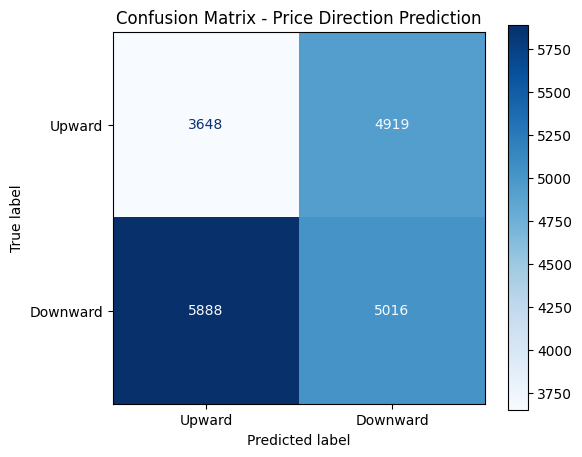

In [ ]:
valid_data = df[['Actual_Direction', 'Predicted_Direction']].dropna()

cm = confusion_matrix(valid_data['Actual_Direction'], valid_data['Predicted_Direction'], labels=[1, -1])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Upward", "Downward"])
disp.plot(cmap="Blues", ax=ax)

plt.title("Confusion Matrix - Price Direction Prediction")
plt.show() 

### **1. Confidence Intervals & Probability Forecasting**

- #### *Can it quantify uncertainty (e.g., 95% probability the price will be between X and Y)?*

In [20]:
train_predictions = lgb_model.predict(X_train)
residuals = y_train - train_predictions

In [21]:
residual_std = np.std(residuals)

In [22]:
test_predictions = lgb_model.predict(X_test)

lower_bound = test_predictions - 1.96 * residual_std
upper_bound = test_predictions + 1.96 * residual_std

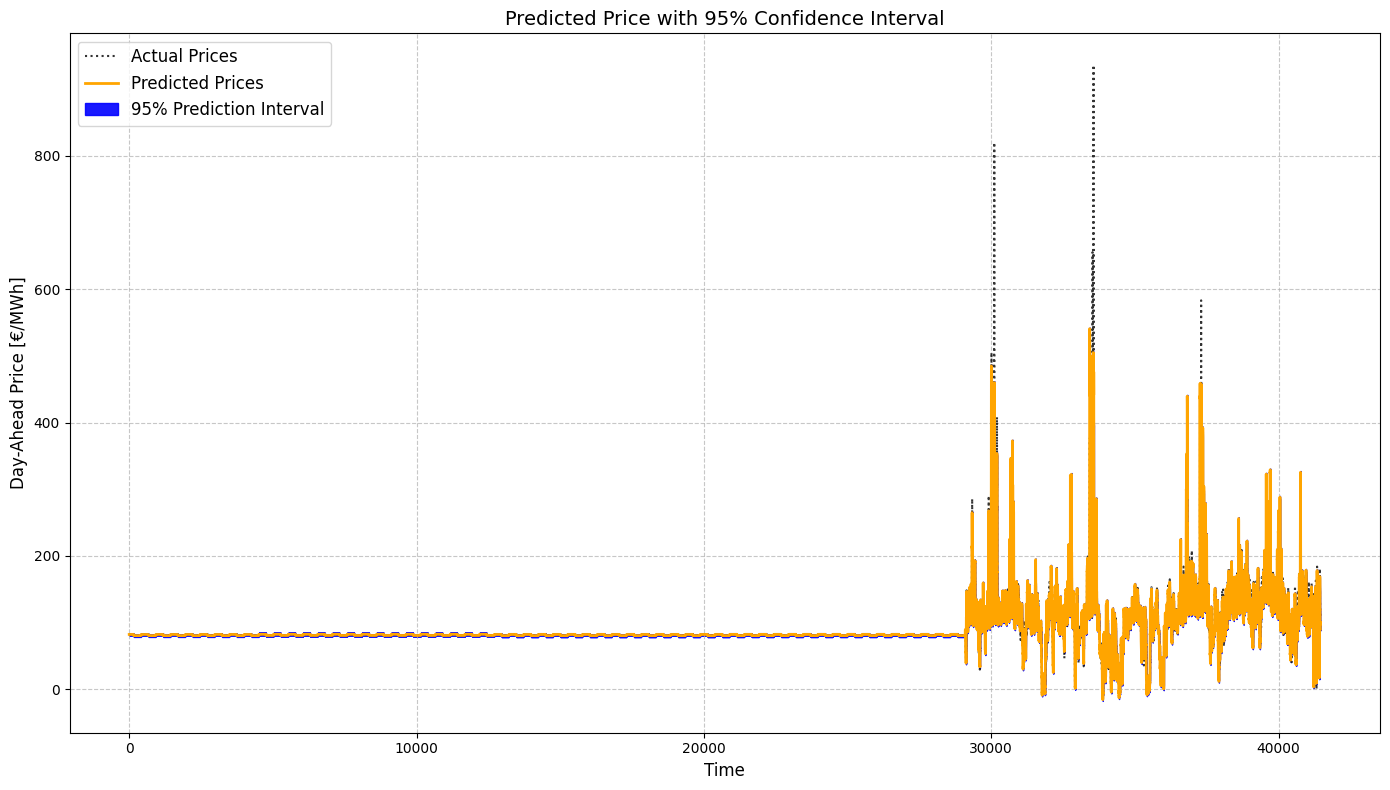

In [ ]:
plt.figure(figsize=(14, 8))
plt.plot(y_test.values, label="Actual Prices", color='black', linestyle='dotted', alpha=0.8)
plt.plot(test_predictions, label="Predicted Prices", color='orange', linewidth=2)
plt.fill_between(range(len(lower_bound)), lower_bound, upper_bound, color='blue', alpha=0.9, label="95% Prediction Interval")
plt.xlabel("Time", fontsize=12)
plt.ylabel("Day-Ahead Price [€/MWh]", fontsize=12)
plt.title("Predicted Price with 95% Confidence Interval", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

In [24]:
min_lower_bound = np.min(lower_bound)
max_upper_bound = np.max(upper_bound)

print(f"95% Prediction Interval: [{min_lower_bound:.2f}, {max_upper_bound:.2f}] €/MWh")

95% Prediction Interval: [-17.54, 542.71] €/MWh


### **2. Interpretability & Feature Importance**

- #### *Feature Importance*

In [25]:
feature_im = lgb_model.booster_.feature_importance(importance_type="gain")

importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': feature_im
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

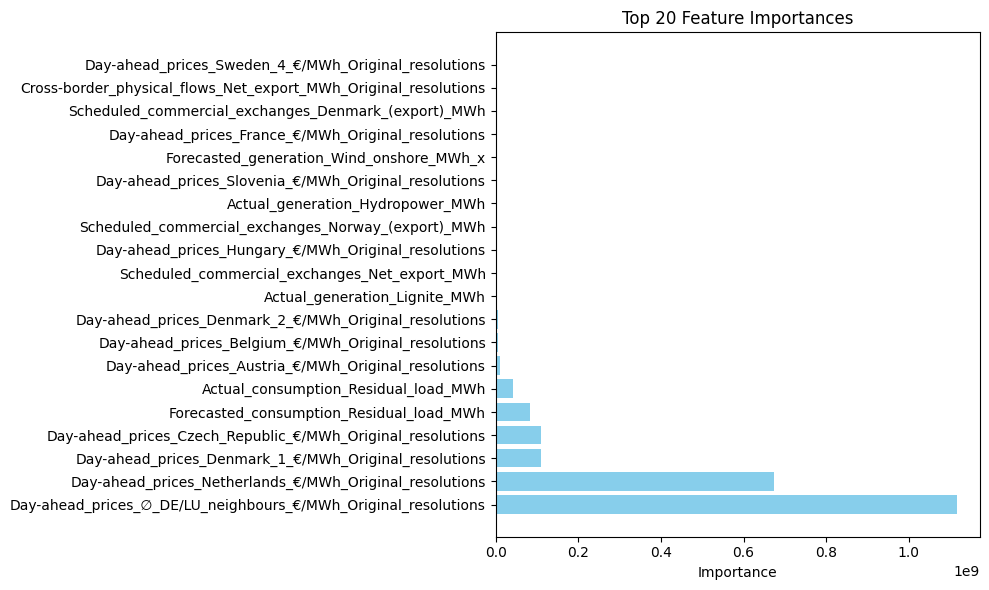

In [29]:
top_features = importance_df.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title(f'Top {20} Feature Importances')
plt.tight_layout()
plt.show()

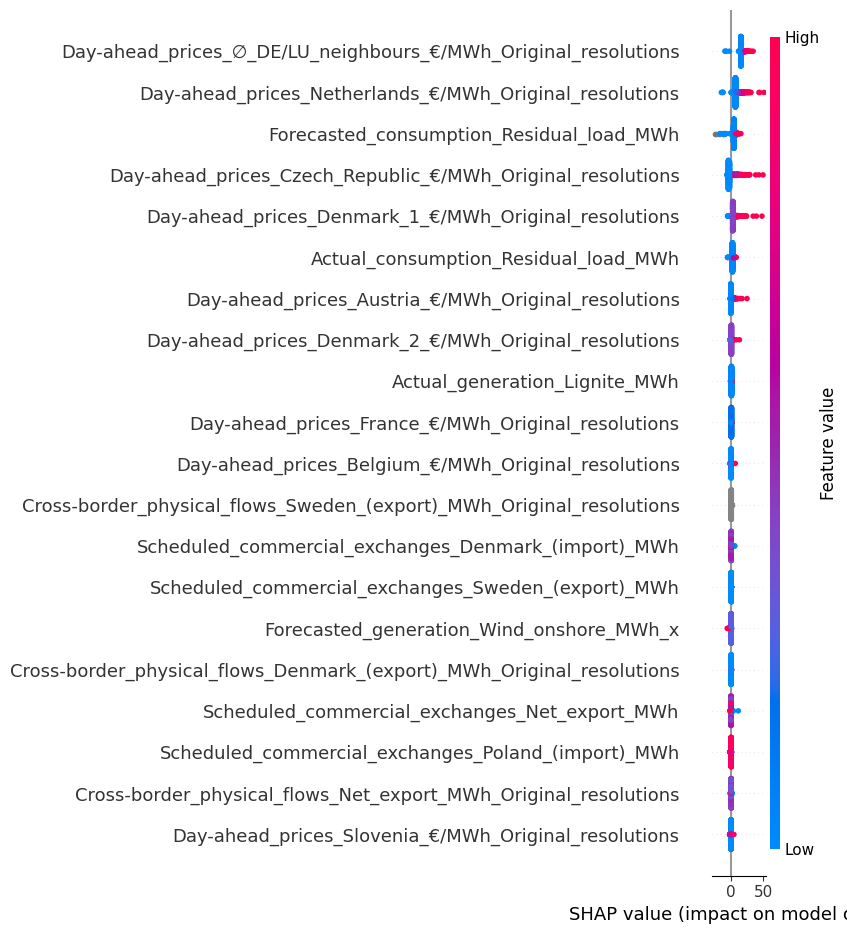

<Figure size 640x480 with 0 Axes>

In [31]:
import shap

explainer = shap.TreeExplainer(lgb_model)
data = X_test.sample(n=500)

shap_values = explainer.shap_values(data)

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, data, show=True)
plt.tight_layout() 
plt.show()

In [26]:
lgb_model.booster_.save_model("lightgbm_model.txt")

In [27]:
import lightgbm as lgb
loaded_model = lgb.Booster(model_file="lightgbm_model.txt")

In [28]:
import pickle

with open('best_model.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)